In [2]:
%pip install clean-text

Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd
from cleantext import clean
import re
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import datasets
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np

In [2]:
data_test = pd.read_csv("186 - emotion-labels-test.csv")
data_train = pd.read_csv("186 - emotion-labels-train.csv")
data_val = pd.read_csv("186 - emotion-labels-val.csv")

In [3]:
data = pd.concat([data_test, data_train, data_val], ignore_index= True)
data.head()

,text,label
0,You must be knowing #blithe means (adj.) Happ...,joy
1,Old saying 'A #smile shared is one gained for ...,joy
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy
3,@Elaminova sparkling water makes your life spa...,joy
4,I'm tired of everybody telling me to chill out...,joy


In [4]:
data['clean'] = data['text'].apply(lambda x: clean(x, no_emoji = True) )

In [5]:
data['clean'] = data['clean'].apply(lambda x: re.sub('@[^\s]+', '', x))
data.head()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_15954/3162287748.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  data['clean'] = data['clean'].apply(lambda x: re.sub('@[^\s]+', '', x))


,text,label,clean
0,You must be knowing #blithe means (adj.) Happ...,joy,you must be knowing #blithe means (adj.) happy...
1,Old saying 'A #smile shared is one gained for ...,joy,old saying 'a #smile shared is one gained for ...
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy,bridget jones' baby was bloody hilarious #brid...
3,@Elaminova sparkling water makes your life spa...,joy,sparkling water makes your life sparkly
4,I'm tired of everybody telling me to chill out...,joy,i'm tired of everybody telling me to chill out...


<Axes: xlabel='count', ylabel='label'>

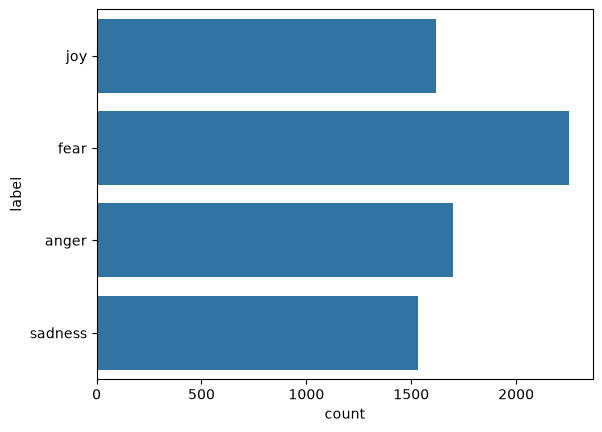

In [6]:
sns.countplot(data['label'],) # use count plot , dont use bar plot , its just the average 

In [7]:
g = data.groupby('label')
g.head()

,text,label,clean
0,You must be knowing #blithe means (adj.) Happ...,joy,you must be knowing #blithe means (adj.) happy...
1,Old saying 'A #smile shared is one gained for ...,joy,old saying 'a #smile shared is one gained for ...
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy,bridget jones' baby was bloody hilarious #brid...
3,@Elaminova sparkling water makes your life spa...,joy,sparkling water makes your life sparkly
4,I'm tired of everybody telling me to chill out...,joy,i'm tired of everybody telling me to chill out...
714,#Matthew 25; 1-13\nCould somebody shoot a #vid...,fear,#matthew 25; 1-13\ncould somebody shoot a #vid...
715,@bkero @whispersystems Which really sucks beca...,fear,which really sucks because typing on a mobil...
716,Be #afraid of the #quiet ones they are the one...,fear,be #afraid of the #quiet ones they are the one...
717,@riinkanei he's a horrible person and now i ga...,fear,he's a horrible person and now i gag when i s...
718,What we fear doing most is usually what we mos...,fear,what we fear doing most is usually what we mos...


In [8]:
g = data.groupby('label')
data = g.apply(lambda x: x.sample(g.size().min()),include_groups = False).reset_index(level = 0).reset_index(drop=True)
data.head()

,label,text,clean
0,anger,@marthalyssa yep. LOL #bitter,yep. lol #bitter
1,anger,When u are strong u offend the weak &amp; inse...,when u are strong u offend the weak & insecure...
2,anger,Egyptian officials expressed frustration and o...,egyptian officials expressed frustration and o...
3,anger,Like he really just fucking asked me that.,like he really just fucking asked me that.
4,anger,hitting your children as discipline because yo...,hitting your children as discipline because yo...


<Axes: xlabel='label', ylabel='count'>

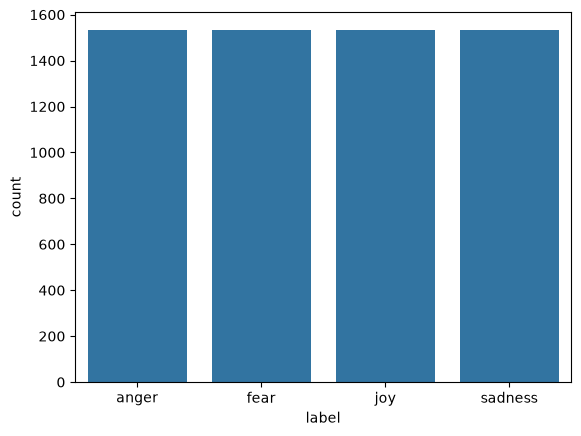

In [9]:
sns.countplot(data= data, x= 'label')

In [10]:
data['label'] = LabelEncoder().fit_transform(data['label'])

In [11]:
Numlabels= 4

In [12]:
train_split, test_split = train_test_split(data, train_size= 0.8)
train_split, val_split = train_test_split(train_split, train_size = 0.9)

In [13]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


building new tables

In [14]:
train_df = pd.DataFrame({
    'label' : train_split.label.values,
    'text' : train_split.clean.values
})

test_df = pd.DataFrame({
    'label' : test_split.label.values,
    'text': test_split.clean.values
})

changing tables to use for machine learning

In [15]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

creating a new dictionary (sb kuch machine learining kylye hrha hai )

In [16]:
dataset_dict = datasets.DatasetDict({"train" : train_df, "test": test_df})

In [17]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

In [18]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [19]:
def tokenizer_function(exapmles):
    return tokenizer(exapmles['text'], padding = "max_length", max_length =  128, truncation = True)

In [20]:
tokenized_dataset =  dataset_dict.map(tokenizer_function, batched = True)

Map: 100%|██████████| 1227/1227 [00:00<00:00, 8006.02 examples/s]


In [21]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [22]:
tokenized_dataset['train']['text'][0]

'watch this amazing live.ly broadcast by  #musically'

In [23]:
print(tokenized_dataset['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1628, 52, 3704, 633, 9, 111, 3037, 37, 17, 7967, 13715, 1279, 4, 3]


In [24]:
print(tokenized_dataset['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [25]:
small_train_dataset = tokenized_dataset["train"].shuffle(seed = 20).select(range(100))
small_eval_dataset = tokenized_dataset['test'].shuffle(seed = 20).select(range(100))

In [26]:
model = XLNetForSequenceClassification.from_pretrained(
    'xlnet-base-cased',
    num_labels = Numlabels,
    id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'}
)

Loading weights: 100%|██████████| 206/206 [00:00<00:00, 14414.86it/s]
[transformers] XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
metric = evaluate.load('accuracy')

In [28]:
def compute_matrices(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis= -1)
    return metric.compute(predictions= predictions, references= labels)

In [29]:
training_args = TrainingArguments(
    output_dir = "test_trainer",
    eval_strategy = "epoch",
    num_train_epochs = 3,
)

In [31]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = small_train_dataset,
    eval_dataset = small_eval_dataset,
    compute_metrics = compute_matrices
)

In [33]:
trainer.train()

/usr/local/python/3.14.2/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.387605,0.350000
2,No log,1.361188,0.320000
3,No log,1.332504,0.340000


/usr/local/python/3.14.2/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/python/3.14.2/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.74it/s]
/usr/local/python/3.14.2/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=39, training_loss=1.3972005599584334, metrics={'train_runtime': 460.62, 'train_samples_per_second': 0.651, 'train_steps_per_second': 0.085, 'total_flos': 21366375321600.0, 'train_loss': 1.3972005599584334, 'epoch': 3.0})